In [1]:
# Librerías
import pandas as pd
import numpy as np
import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

import tensorflow as tf 
from tensorflow import keras 

In [2]:
import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [3]:
#Leemos el archivo excel

df=pd.read_excel("datos.xlsx", header=0)
# Media de temperatura y humedad de las últimas 72 horas
# Esto le dice al modelo si el terreno viene "calentándose" días atrás
df['temp_media_3d'] = df['temperature_2m (°C)'].rolling(window=72).mean()
df['hum_media_3d'] = df['relative_humidity_2m (%)'].rolling(window=72).mean()

# Variación de presión en las últimas 6 horas (Detección de frentes)
df['delta_presion_6h'] = df['surface_pressure (hPa)'].diff(6)

df=df.dropna(axis=0)
print(df)

                     time  temperature_2m (°C)  relative_humidity_2m (%)  \
71    2017-01-06 23:00:00                  8.3                        95   
72    2017-01-07 00:00:00                  7.9                        96   
73    2017-01-07 01:00:00                  7.1                        97   
74    2017-01-07 02:00:00                  7.0                        97   
75    2017-01-07 03:00:00                  6.9                        97   
...                   ...                  ...                       ...   
70051 2024-12-31 19:00:00                  9.4                        77   
70052 2024-12-31 20:00:00                  8.0                        83   
70053 2024-12-31 21:00:00                  7.4                        87   
70054 2024-12-31 22:00:00                  6.6                        88   
70055 2024-12-31 23:00:00                  5.9                        89   

       surface_pressure (hPa)  wind_speed_10m (km/h)  wind_direction_10m (°)  \
71     

In [4]:
# Contamos los missing values
df.isnull().sum()

time                        0
temperature_2m (°C)         0
relative_humidity_2m (%)    0
surface_pressure (hPa)      0
wind_speed_10m (km/h)       0
wind_direction_10m (°)      0
wind_speed_100m (km/h)      0
wind_direction_100m (°)     0
wind_gusts_10m (km/h)       0
incendio                    0
temp_t-1                    0
temp_t-24                   0
hum_t-1                     0
hum_t-24                    0
presion_t-1                 0
presion_t-2                 0
temp_media_3d               0
hum_media_3d                0
delta_presion_6h            0
dtype: int64

Eliminamos las primeras filas porque contienen la información de la localización y no nos interesa para entrenar los datos. También quitamos los valores faltantes.

In [5]:
df=df.dropna(axis=0) #axis=0 elimina filas, axis=1 columnas donde valores ausentes en algunas filas

Ya hemos limpiado los datos de valores faltantes, ahora vamos a ver si hay outliers.


In [6]:
df.describe()

,time,temperature_2m (°C),relative_humidity_2m (%),surface_pressure (hPa),wind_speed_10m (km/h),wind_direction_10m (°),wind_speed_100m (km/h),wind_direction_100m (°),wind_gusts_10m (km/h),incendio,temp_t-1,temp_t-24,hum_t-1,hum_t-24,presion_t-1,presion_t-2,temp_media_3d,hum_media_3d,delta_presion_6h
count,69985,69985.000000,69985.000000,69985.000000,69985.000000,69985.000000,69985.000000,69985.000000,69985.000000,69985.00000,69985.000000,69985.000000,69985.000000,69985.000000,69985.000000,69985.000000,69985.000000,69985.000000,69985.000000
mean,2021-01-03 23:00:00,18.559003,67.755362,1017.389616,10.261612,192.049496,17.259538,192.691305,21.668830,0.01316,18.559081,18.559844,67.755319,67.757234,1017.389595,1017.389576,18.560123,67.758559,0.000113
min,2017-01-06 23:00:00,-1.900000,4.000000,986.200000,0.000000,1.000000,0.000000,1.000000,1.400000,0.00000,-1.900000,-1.900000,4.000000,4.000000,986.200000,986.200000,4.541667,19.305556,-15.600000
25%,2019-01-05 23:00:00,13.300000,51.000000,1013.700000,6.600000,73.000000,10.900000,77.000000,12.600000,0.00000,13.300000,13.300000,51.000000,51.000000,1013.700000,1013.700000,13.570833,58.291667,-1.100000
50%,2021-01-03 23:00:00,18.100000,70.000000,1016.500000,9.100000,229.000000,17.100000,228.000000,19.100000,0.00000,18.100000,18.100000,70.000000,70.000000,1016.500000,1016.500000,18.088889,68.986111,0.100000
75%,2023-01-02 23:00:00,23.300000,87.000000,1021.000000,13.100000,270.000000,22.500000,269.000000,28.400000,0.00000,23.300000,23.300000,87.000000,87.000000,1021.000000,1021.000000,23.505556,78.083333,1.100000
max,2024-12-31 23:00:00,44.400000,100.000000,1038.200000,47.900000,360.000000,76.400000,360.000000,108.400000,1.00000,44.400000,44.400000,100.000000,100.000000,1038.200000,1038.200000,33.823611,93.444444,19.800000
std,NaN,7.317613,21.857064,5.723293,5.380293,106.274305,8.596551,103.713181,11.258797,0.11396,7.317507,7.316508,21.857025,21.857102,5.723255,5.723224,5.972905,13.120479,1.625469


In [7]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['time', 'incendio'])
y = df['incendio']
# 3. División en entrenamiento y prueba (80% tren, 20% test)
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)
original_column_names = list(X_train.columns)


In [8]:
model = keras.models.Sequential()
model.add(keras.Input(shape=(X_train.shape[1],)))
model.add(keras.layers.Dense(32, activation="relu")) #Antes 16, 32
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(16, activation="relu")) # 8, 16
model.add(keras.layers.Dropout(0.3))
#model.add(keras.layers.Dense(8, activation="relu"))  #Nueva capa 8
model.add(keras.layers.Dense(1, activation="sigmoid")) #1 porque solo hay una clase y sigmoid porque se trata de clas. binaria


In [9]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",  # para clasificación binaria
    metrics=["recall"]
)
# Early Stopping para no entrenar épocas en vano
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [10]:
from sklearn.utils import class_weight

# Calcula los pesos automáticamente
weights = class_weight.compute_class_weight('balanced', 
                                            classes=np.unique(Y_train), 
                                            y=Y_train)
dict_weights = dict(enumerate(weights))


history = model.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,  # valida 20% de train
    verbose=2,
    class_weight=dict_weights,
    callbacks=[early_stop]
)


Epoch 1/20
1400/1400 - 5s - 4ms/step - loss: 15.3147 - recall: 0.5484 - val_loss: 0.7477 - val_recall: 1.0000
Epoch 2/20
1400/1400 - 3s - 2ms/step - loss: 1.2404 - recall: 0.8131 - val_loss: 0.7652 - val_recall: 1.0000
Epoch 3/20
1400/1400 - 3s - 2ms/step - loss: 0.8010 - recall: 0.9083 - val_loss: 0.7427 - val_recall: 1.0000
Epoch 4/20
1400/1400 - 3s - 2ms/step - loss: 0.7621 - recall: 0.9048 - val_loss: 0.7189 - val_recall: 1.0000
Epoch 5/20
1400/1400 - 4s - 3ms/step - loss: 0.7249 - recall: 0.9221 - val_loss: 0.7139 - val_recall: 1.0000
Epoch 6/20
1400/1400 - 4s - 3ms/step - loss: 0.6969 - recall: 0.8962 - val_loss: 0.7005 - val_recall: 1.0000
Epoch 7/20
1400/1400 - 4s - 3ms/step - loss: 0.6993 - recall: 0.7145 - val_loss: 0.6998 - val_recall: 1.0000
Epoch 8/20
1400/1400 - 3s - 2ms/step - loss: 0.6973 - recall: 0.4723 - val_loss: 0.6913 - val_recall: 0.0000e+00
Epoch 9/20
1400/1400 - 3s - 2ms/step - loss: 0.7459 - recall: 0.3633 - val_loss: 0.6850 - val_recall: 0.0000e+00
Epoch 10/2

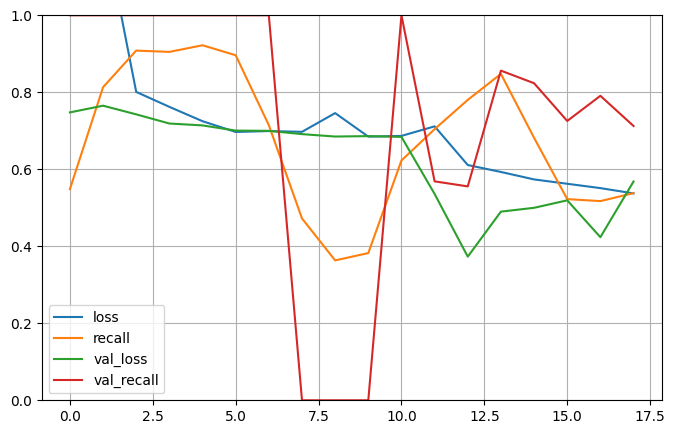

In [11]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [12]:
loss, accuracy = model.evaluate(X_test, Y_test, verbose=0)
print(f"Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")


Loss: 0.3727, Accuracy: 0.5947


In [13]:

from sklearn.metrics import f1_score

Y_pred = (model.predict(X_test) > 0.5).astype(int)

# Calcular F1 score
score = f1_score(Y_test, Y_pred)
print("F1 Score:", score)


438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
F1 Score: 0.12034078807241747


In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, Y_pred)
print(cm)


[[12232  1575]
 [   77   113]]


In [15]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV

In [16]:
# Definimos una función que crea el modelo (necesaria para el wrapper)
from tensorflow import keras
from tensorflow.keras import layers

def create_model(hidden_layers=1, neurons=32, dropout_rate=0.0, meta=None):
    model = keras.models.Sequential()
    
    input_dim = meta["n_features_in_"]
    model.add(keras.Input(shape=(input_dim,)))
    
    for _ in range(hidden_layers):
        model.add(layers.Dense(neurons, activation="relu"))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))
    
    model.add(layers.Dense(1, activation="sigmoid"))
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.Recall(name="recall")]
    )
    
    return model

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',           # <--- CAMBIA ESTO (de val_loss a loss)
    patience=5, 
    restore_best_weights=True # Muy importante para quedarse con el mejor punto
)
# Creamos el objeto estimador
model_wrapper = KerasClassifier(
    model=create_model,
    verbose=0,
    callbacks=[early_stop]
)

In [17]:
print(model_wrapper.get_params().keys())

dict_keys(['model', 'build_fn', 'warm_start', 'random_state', 'optimizer', 'loss', 'metrics', 'batch_size', 'validation_batch_size', 'verbose', 'callbacks', 'validation_split', 'shuffle', 'run_eagerly', 'epochs', 'class_weight'])


In [18]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', model_wrapper)
])
# Definimos qué queremos probar 
param_grid = { 'mlp__model__hidden_layers': [1, 2], # Probar con 1 o 2 capas ocultas 
              'mlp__model__neurons': [16, 32], # Probar diferentes anchos 16, 32
              'mlp__batch_size': [16, 32], # Probar diferentes tamaños de lote 16,32 
              'mlp__model__dropout_rate': [0.0, 0.1],
              'mlp__epochs': [20]
             } 
from sklearn.model_selection import GridSearchCV 
# Configuramos la búsqueda aleatoria 
grid_search = GridSearchCV( estimator= pipeline, 
                           param_grid=param_grid, 
                           cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
                           scoring='f1', # Optimizamos para Recall como querías 
                           verbose=2,
                           n_jobs=1
                          ) # Ejecutar búsqueda (usa class_weight si tu dataset sigue desbalanceado) 
grid_result = grid_search.fit(X_train, Y_train, 
                              mlp__class_weight=dict_weights,
                              mlp__validation_split=0.2) 
# 4. Ver resultados del mejor modelo print(f"Mejor Recall: {grid_result.best_score_}") 
print(f"Mejores parámetros: {grid_result.best_params_}")

Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV] END mlp__batch_size=16, mlp__epochs=20, mlp__model__dropout_rate=0.0, mlp__model__hidden_layers=1, mlp__model__neurons=16; total time= 1.2min
[CV] END mlp__batch_size=16, mlp__epochs=20, mlp__model__dropout_rate=0.0, mlp__model__hidden_layers=1, mlp__model__neurons=16; total time= 1.2min
[CV] END mlp__batch_size=16, mlp__epochs=20, mlp__model__dropout_rate=0.0, mlp__model__hidden_layers=1, mlp__model__neurons=16; total time= 1.2min
[CV] END mlp__batch_size=16, mlp__epochs=20, mlp__model__dropout_rate=0.0, mlp__model__hidden_layers=1, mlp__model__neurons=32; total time= 1.2min
[CV] END mlp__batch_size=16, mlp__epochs=20, mlp__model__dropout_rate=0.0, mlp__model__hidden_layers=1, mlp__model__neurons=32; total time= 1.2min
[CV] END mlp__batch_size=16, mlp__epochs=20, mlp__model__dropout_rate=0.0, mlp__model__hidden_layers=1, mlp__model__neurons=32; total time= 1.3min
[CV] END mlp__batch_size=16, mlp__epochs=20, mlp__model__

Threshold óptimo: 0.89998835
Precision: 0.28421052631578947
Recall: 0.5684210526315789
[[12482  1325]
 [   21   169]]


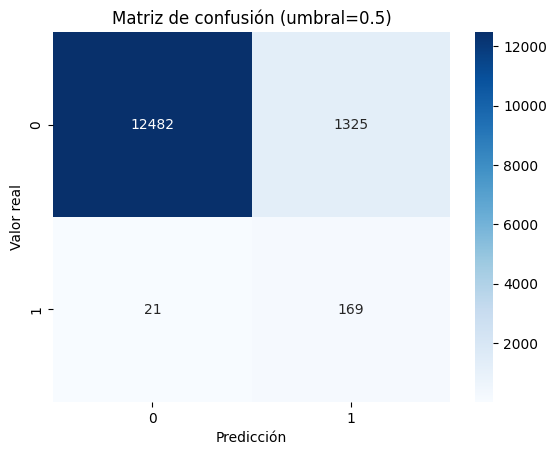

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# 🔹 1. Probabilidades (IMPORTANTÍSIMO)
# Probabilidades de clase positiva
y_prob = grid_result.best_estimator_.predict_proba(X_test)[:, 1]

# Curva Precision-Recall
precisions, recalls, thresholds = precision_recall_curve(Y_test, y_prob)

# Buscar threshold que mantenga Recall >= 0.90 y maximice Precision
target_recall = 0.5
idx = np.where(recalls >= target_recall)[0]  # todos los thresholds con Recall >= 0.9
best_idx = idx[np.argmax(precisions[idx])]    # entre ellos, escoger el que da mayor Precision
best_threshold = thresholds[best_idx]

print("Threshold óptimo:", best_threshold)
print("Precision:", precisions[best_idx])
print("Recall:", recalls[best_idx])

# Aplicar threshold
Y_pred = (y_prob >= 0.5).astype(int)
threshold=0.5
# Matriz de confusión final
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, Y_pred)
print(cm)
# 🔹 5. Visualización
import seaborn as sns


sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title(f"Matriz de confusión (umbral={threshold})")
plt.show()

In [21]:
print(dict_weights)

{0: np.float64(0.5066145465732849), 1: np.float64(38.29548563611491)}


In [22]:
print(np.mean(Y_train))
print(np.mean(Y_test))

0.013056369221976137
0.013574337358005287


Vemos que F1 Score es muy bajo ya que nuestro dataset está muy desbalanceado, por tanto, vamos a usar class weight para que la clase minoritaria(Incendio) tenga más peso.

In [23]:
from sklearn.metrics import precision_score, recall_score

Y_pred = (grid_result.best_estimator_.predict(X_test) > 0.1).astype(int)


print("Recall:", recall_score(Y_test, Y_pred))
print("Precision:", precision_score(Y_test, Y_pred))
print("F1 Score:", f1_score(Y_test, Y_pred))

Recall: 0.8894736842105263
Precision: 0.11311914323962517
F1 Score: 0.2007125890736342


[[12482  1325]
 [   21   169]]
Min: 0.0
Max: 0.9970339
Ejemplo: [6.3080912e-34 1.1557540e-37 4.7553882e-01 0.0000000e+00 0.0000000e+00
 1.1609579e-07 1.6589573e-05 0.0000000e+00 0.0000000e+00 4.3363860e-01]


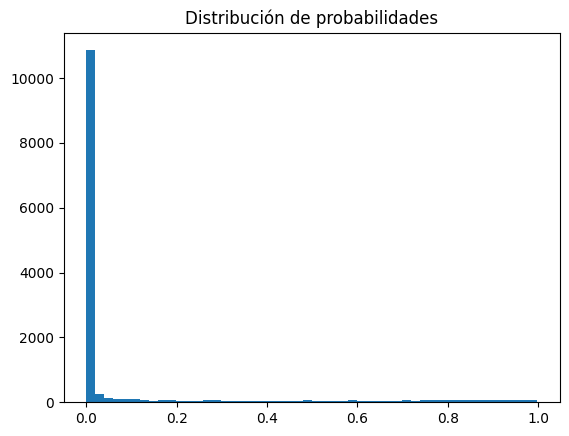


Threshold 0.1
FP: 2373, FN: 5

Threshold 0.2
FP: 2041, FN: 10

Threshold 0.5
FP: 1325, FN: 21

Threshold 0.6
FP: 1085, FN: 28


In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, Y_pred)
print(cm)

y_prob = grid_result.best_estimator_.predict_proba(X_test)[:, 1]

print("Min:", y_prob.min())
print("Max:", y_prob.max())
print("Ejemplo:", y_prob[:10])
plt.hist(y_prob, bins=50)
plt.title("Distribución de probabilidades")
plt.show()
y_prob = grid_result.best_estimator_.predict_proba(X_test)[:, 1]

for t in [0.1, 0.2, 0.5, 0.6]:
    y_pred = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(Y_test, y_pred).ravel()
    
    print(f"\nThreshold {t}")
    print(f"FP: {fp}, FN: {fn}")

Mejor threshold (F1): 0.8699506
Precision: 0.27593360995850624
Recall: 0.7
F1: 0.39583332927738807


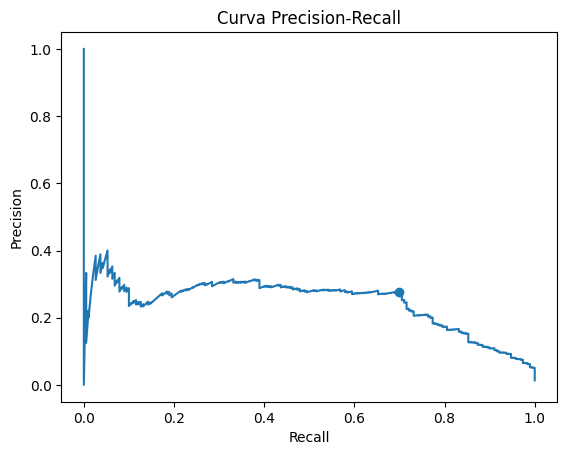

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Probabilidades
y_prob = grid_result.best_estimator_.predict_proba(X_test)[:, 1]

# Curva Precision-Recall
precision, recall, thresholds = precision_recall_curve(Y_test, y_prob)

# 🔹 Calcular F1 para cada umbral
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

# 🔹 Mejor umbral según F1
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Mejor threshold (F1):", best_threshold)
print("Precision:", precision[best_idx])
print("Recall:", recall[best_idx])
print("F1:", f1_scores[best_idx])

# 📈 Gráfica Precision-Recall
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")

# Punto óptimo
plt.scatter(recall[best_idx], precision[best_idx])
plt.show()

In [26]:
# Queremos recall >= 0.90
target_recall = 0.90

idx = np.where(recall >= target_recall)[0][-1]
threshold_recall = thresholds[idx]

print("Threshold con recall >= 0.90:", threshold_recall)
print("Precision:", precision[idx])
print("Recall:", recall[idx])

Threshold con recall >= 0.90: 0.4893504
Precision: 0.1119109947643979
Recall: 0.9


Index([48687, 48688, 48689, 48690, 48691, 48692, 48693, 48694, 48695, 48696,
       48697, 48698, 48699, 48700, 48701, 48702, 48703, 48704, 48705, 48706,
       48707, 48708, 48709, 48710, 48711, 48712, 48713, 48714, 48715, 48716,
       48717, 48718, 48719, 48720, 48721, 48722, 48723, 48724, 48725, 48726,
       48727, 48728, 48729, 48730, 48731, 48732, 48733, 48734, 48735, 48736,
       48737, 48738, 48739, 48740, 48741, 48742, 48743, 48744, 48745, 48746,
       48747, 48748, 48749, 48750, 48751, 48752, 48753, 48754, 48755, 48756,
       48757, 48758, 48759, 48760, 48761, 48762, 48763, 48764, 48765, 48766,
       48767],
      dtype='int64')


C:\Users\silvi\AppData\Local\Temp\ipykernel_2656\4205262520.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_incendio_test['fecha'] = df.loc[df_incendio_test.index, df.columns[0]]


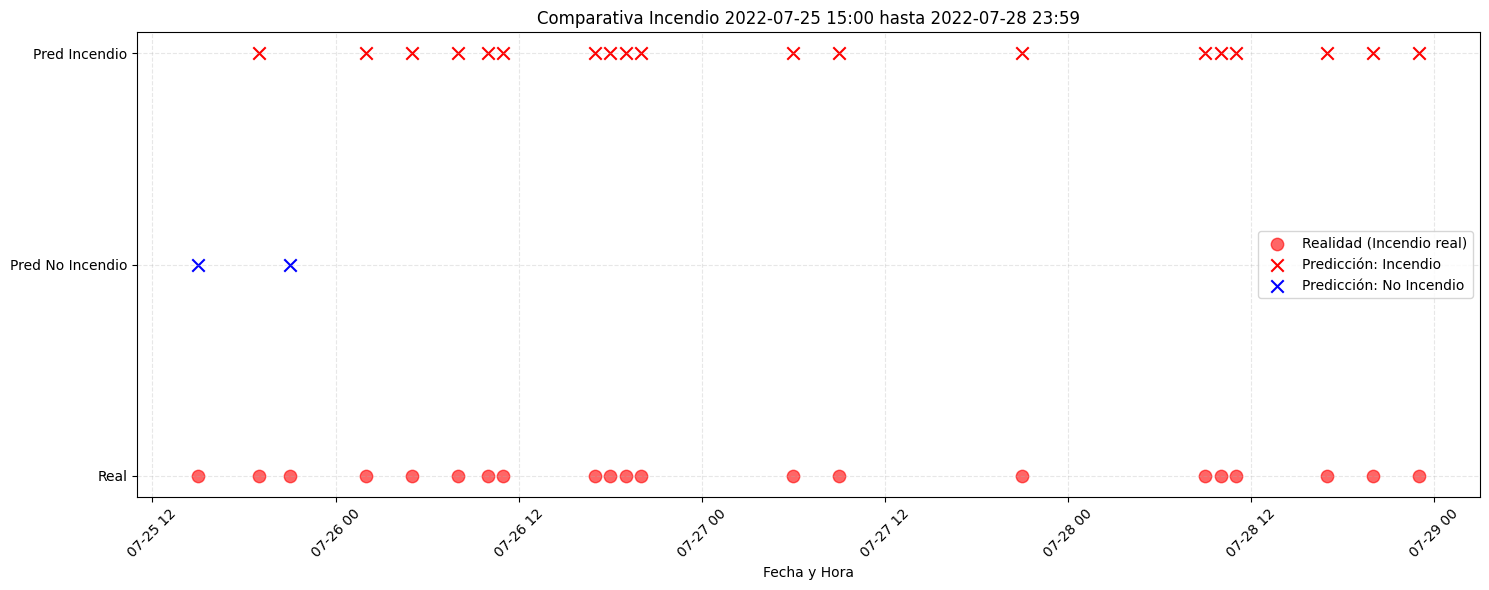

Se han detectado 19 horas del incendio de 21 horas. 


In [27]:
# 1. Buscamos los índices (los números de la izquierda) que corresponden a esas fechas
mask_incendio = (df.iloc[:, 0] >= "2022-07-25 15:00") & (df.iloc[:, 0] <= "2022-07-28 23:59")
indices_incendio = df[mask_incendio].index

print(indices_incendio)
# 2. Creamos un DataFrame de resultados uniendo y_test e y_pred_opt
# Importante: X_test conserva el índice original (ej: 71, 72...)
df_resultados = pd.DataFrame({
    'real': Y_test,
    'prediccion': Y_pred
}, index=Y_test.index)

df_resultados
# 3. Filtramos df_resultados usando solo los índices que encontramos en el paso 1
# Esto selecciona solo las filas del incendio que cayeron en tu set de TEST
df_incendio_test = df_resultados.loc[df_resultados.index.isin(indices_incendio)]

df_incendio_test

# 4. Recuperamos las fechas para el eje X
df_incendio_test['fecha'] = df.loc[df_incendio_test.index, df.columns[0]]
df_incendio_test = df_incendio_test.sort_values('fecha')
 
df_incendio_test
# --- Visualización ---
plt.figure(figsize=(15, 6))

# --- REALIDAD: siempre abajo en rojo ---
plt.scatter(
    df_incendio_test['fecha'], 
    [0]*len(df_incendio_test),   # todos abajo
    color='red', 
    label='Realidad (Incendio real)', 
    s=80, 
    alpha=0.6
)

# --- PREDICCIONES ---
# Predicción = 1 (Incendio) -> cruces rojas arriba
pred_si = df_incendio_test[df_incendio_test['prediccion'] == 1]
plt.scatter(
    pred_si['fecha'], 
    [1]*len(pred_si), 
    color='red', 
    marker='x', 
    label='Predicción: Incendio', 
    s=80
)

# Predicción = 0 (No incendio) -> cruces azules a otra altura
pred_no = df_incendio_test[df_incendio_test['prediccion'] == 0]
plt.scatter(
    pred_no['fecha'], 
    [0.5]*len(pred_no),  # altura intermedia
    color='blue', 
    marker='x', 
    label='Predicción: No Incendio', 
    s=80
)

# Ejes y estilo
plt.yticks([0, 0.5, 1], ['Real', 'Pred No Incendio', 'Pred Incendio'])
plt.title('Comparativa Incendio 2022-07-25 15:00 hasta 2022-07-28 23:59')
plt.xlabel('Fecha y Hora')
plt.grid(True, axis='both', linestyle='--', alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Finalmente, contamos cuantas horas de incendio predice bien

total_incendios_predichos = df_incendio_test['prediccion'].sum()

print(f'Se han detectado {total_incendios_predichos} horas del incendio de {len(df_incendio_test)} horas. ' )

In [28]:
from sklearn.inspection import permutation_importance

X_test_df = pd.DataFrame(X_test, columns=original_column_names)

result = permutation_importance(
    grid_search.best_estimator_, 
    X_test_df,
    Y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importancia = pd.DataFrame({
    'Variable': original_column_names,
    'Importancia': result.importances_mean
}).sort_values(by='Importancia', ascending=False)

print(importancia)

                    Variable  Importancia
9                  temp_t-24     0.033207
1   relative_humidity_2m (%)     0.029749
3      wind_speed_10m (km/h)     0.005951
5     wind_speed_100m (km/h)     0.004622
6    wind_direction_100m (°)     0.004437
7      wind_gusts_10m (km/h)     0.001607
0        temperature_2m (°C)    -0.001443
4     wind_direction_10m (°)    -0.002036
16          delta_presion_6h    -0.005951
12               presion_t-1    -0.006166
8                   temp_t-1    -0.009445
13               presion_t-2    -0.010745
11                  hum_t-24    -0.016075
10                   hum_t-1    -0.017225
2     surface_pressure (hPa)    -0.018118
15              hum_media_3d    -0.029892
14             temp_media_3d    -0.044552


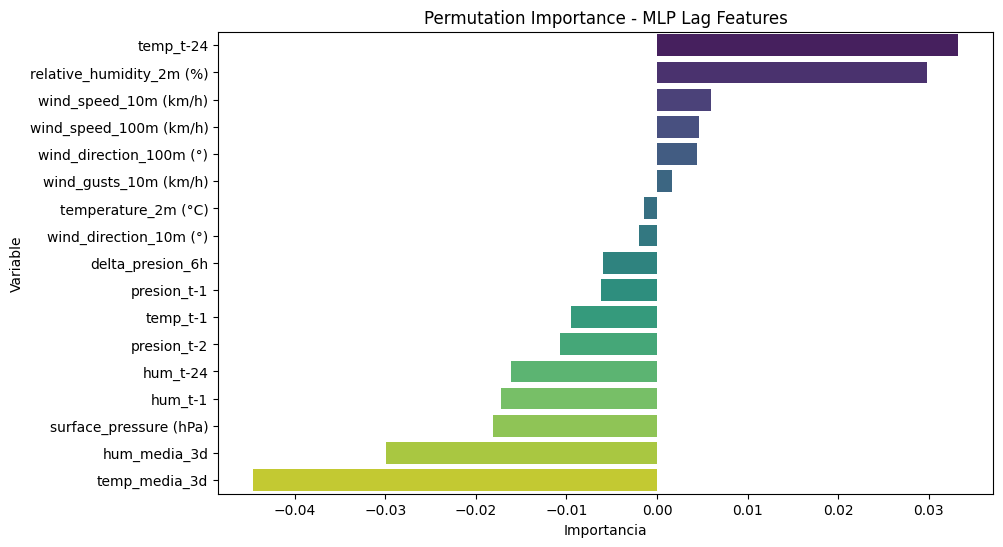

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10,6))
sns.barplot(x='Importancia', y='Variable', data=importancia, hue='Variable',
    dodge=False,
    palette='viridis')
plt.title("Permutation Importance - MLP Lag Features")
plt.show()

In [30]:
import joblib

joblib.dump(grid_search.best_estimator_, 'modelo_mlp_lag.pkl')

['modelo_mlp_lag.pkl']